# Análise de dados de Sistema de Monitoramento

O presente trabalho tem como objetivo analisar os dados das avaliações Formativa 3 aplicadas à parte das turmas do programa PBA Sergipe para entender a eficácia pedagógica do programa através de seus instrumentos. Serão analisadas somente 35 turmas que tiverem início posterior ao das demais turmas regulares. As turmas a serem estudadas são as seguintes:

TURMA-P0000123-0001; 
TURMA-P0000122-0001; 
TURMA-P0000122-0002; 
TURMA-28009398-0017; 
TURMA-28010450-0006; 
TURMA-28032730-0006; 
TURMA-28018575-0016; 
TURMA-28023315-0007; 
TURMA-28023315-0008; 
TURMA-28023315-0009; 
TURMA-28020766-0004; 
TURMA-28020766-0012; 
TURMA-28020472-0005; 
TURMA-28020472-0006; 
TURMA-28011058-0008; 
TURMA-28005201-0006; 
TURMA-28006569-0004; 
TURMA-28006569-0005; 
TURMA-28020529-0004; 
TURMA-28020529-0005; 
TURMA-28028562-0006; 
TURMA-28003551-0007; 
TURMA-28020421-0004; 
TURMA-28010434-0001; 
TURMA-28026667-0028; 
TURMA-28026667-0029; 
TURMA-28026667-0030; 
TURMA-28026667-0031; 
TURMA-28026667-0032; 
TURMA-28026667-0033; 
TURMA-28026667-0034; 
TURMA-28020804-0003; 
TURMA-28009576-0001; 
TURMA-28006950-0005; 
TURMA-28009983-0005.

## Importando bibliotecas e dados

In [1]:
# Importando bibliotecas
import pandas as pd
import re
import matplotlib.pyplot as plt
from matplotlib import patheffects
import seaborn as sns
import os
import geopandas as gpd
import contextily as ctx
import textwrap
import pandas as pd
from statistics import mode, median, StatisticsError
import numpy as np
from scipy.stats import chi2_contingency, wilcoxon

# Importando arquivo
df_cadastro = pd.read_excel(
    'Data_files/public_data/xls_pedagogico_20102025.xlsx')
df_turmas = pd.read_excel(
    'Data_files/public_data/turmas_20102025.xlsx')
df_registros = pd.read_excel(
    'Data_files/public_data/xls_detalhado_20102025.xlsx')
df_relatorios_diagnostica = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_diagnostica_20102025.xlsx')
df_relatorios_formativa1 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa1_20102025.xlsx')
df_relatorios_formativa2 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa2_20102025.xlsx')
df_relatorios_formativa3 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa3_20102025.xlsx')
df_relatorios_formativa4 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa4_20102025.xlsx')
df_relatorios_somativa = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_somativa_20102025.xlsx')

print('df_cadastro:')
print(df_cadastro.info())
#print(df_cadastro.head())

print('df_turmas:')
print(df_turmas.info())
#print(df_turmas.head())

print('df_registros:')
print(df_registros.info())
#print(df_registros.head())

print('df_relatorios_diagnostica:')
print(df_relatorios_diagnostica.info())
#print(df_relatorios_diagnostica.head())

print('df_relatorios_formativa1:')
print(df_relatorios_formativa1.info())
#print(df_relatorios_formativa1.head())

print('df_relatorios_formativa2:')
print(df_relatorios_formativa2.info())
#print(df_relatorios_formativa2.head())

print('df_relatorios_formativa3:')
print(df_relatorios_formativa3.info())
#print(df_relatorios_formativa3.head())

print('df_relatorios_formativa4:')
print(df_relatorios_formativa4.info())
#print(df_relatorios_formativa4.head())

print('df_relatorios_somativa:')
print(df_relatorios_somativa.info())
#print(df_relatorios_somativa.head())


df_cadastro:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4633 entries, 0 to 4632
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   CPF                        4633 non-null   object
 1   Nome                       4633 non-null   object
 2   Turma                      4633 non-null   object
 3   Data de início             4633 non-null   object
 4   Alfabetizador              4633 non-null   object
 5   Coordenador                4633 non-null   object
 6   Qtde presença              4633 non-null   int64 
 7   Qtde ausência              4633 non-null   int64 
 8   Atividade - Entrada        4627 non-null   object
 9   Atividade - Formativa 1    4627 non-null   object
 10  Atividade - Formativa 2    4550 non-null   object
 11  Atividade - Formativa 3    3870 non-null   object
 12  Atividade - Formativa 4    3489 non-null   object
 13  Atividade - Saída          3285 non-null   object


## Tratando dos dados
Se faz necessário a transformação dos dados para que seja mais fácil sua análise. De acordo com a observação dos dados apresentados, as seguintes transformações serão necessárias:
Em df_registros:
- Transformar nomes de cada coluna para o padrão snake_case;
- Extrair somente os níveis da coluna "Nível";
- Deixar os níveis de maneira categórica corretamente para melhor análise na coluna "Nível".

Em df_relatorios
- Transformar nomes de cada coluna para o padrão snake_case;
- As colunas que contém perguntas serão reduzidas somente a palavra "pergunta" seguida do seu número, exemplo: pergunta_1
- As categorias de resposta serão resumidas em no máximo 3 palavras para facilitar a interpretação - um dicionário será criado aqui.

Em df_cadastro, df_turmas, df_relatorios_(diagnostica / formativa1, 2 e 3):
- Todas as colunas que contem datas deverão ser tranformados para o tipo datetime.

In [2]:
# Transformando nomes de colunas para padrão snake_case
# Função para converter para snake_case
def to_snake_case(column_name):
    return (
        column_name
        .lower()  # Converte tudo para minúsculo
        .replace(' ', '_')  # Substitui espaços por underscore
        .replace('é', 'e')  # Remove acentos
        .replace('ã', 'a')
        .replace('ç', 'c')
        .replace('í', 'i')
        .replace('ó', 'o')
        .replace('ú', 'u')
        .replace('á', 'a')
    )

# Função para extrair o número de perguntas e renomear
def renomear_perguntas(nome_coluna):
    match = re.match(r'^(\d+)\._', nome_coluna)  # Procura o padrão "X._" no início
    if match:
        numero = match.group(1)
        return f'pergunta_{numero}'
    return nome_coluna  # Mantém o nome original se não for uma pergunta numerada

# Aplica a função to_snake_case aos nomes das colunas
df_cadastro.columns = [to_snake_case(col) for col in df_cadastro.columns]
df_turmas.columns = [to_snake_case(col) for col in df_turmas.columns]
df_registros.columns = [to_snake_case(col) for col in df_registros.columns]
df_relatorios_diagnostica.columns = [to_snake_case(col) for col in df_relatorios_diagnostica.columns]
df_relatorios_formativa1.columns = [to_snake_case(col) for col in df_relatorios_formativa1.columns]
df_relatorios_formativa2.columns = [to_snake_case(col) for col in df_relatorios_formativa2.columns]
df_relatorios_formativa3.columns = [to_snake_case(col) for col in df_relatorios_formativa3.columns]
df_relatorios_formativa4.columns = [to_snake_case(col) for col in df_relatorios_formativa4.columns]
df_relatorios_somativa.columns = [to_snake_case(col) for col in df_relatorios_somativa.columns]

# Aplica a função renomear_perguntas a todas as colunas
df_relatorios_diagnostica.columns = [renomear_perguntas(col) for col in df_relatorios_diagnostica.columns]

# Extraindo somente os dados de nível em df_registros
df_registros['nivel'] = df_registros['nivel'].str.extract(r'(Nível [1-3])')

# Ordenando nívels de maneira categórica corretamente
df_registros['nivel'] = pd.Categorical(
    df_registros['nivel'],
    categories=['Nível 1', 'Nível 2', 'Nível 3'],
    ordered=True)

# Verificando os tipos de dados e informações das colunas
#print(df_cadastro.info())
#print(df_turmas.info())
#print(df_registros.info())
#print(df_relatorios_diagnostica.info())


### Extração das 35 turmas a serem analisadas
Antes de iniciar as análises, vamos extrair somente os dados das 35 turmas que precisamos e descartar todo o resto.

In [3]:
# Lista das turmas que você quer filtrar
turmas_selecionadas = [
    "TURMA-P0000123-0001", "TURMA-P0000122-0001", "TURMA-P0000122-0002",
    "TURMA-28009398-0017", "TURMA-28010450-0006", "TURMA-28032730-0006",
    "TURMA-28018575-0016", "TURMA-28023315-0007", "TURMA-28023315-0008",
    "TURMA-28023315-0009", "TURMA-28020766-0004", "TURMA-28020766-0012",
    "TURMA-28020472-0005", "TURMA-28020472-0006", "TURMA-28011058-0008",
    "TURMA-28005201-0006", "TURMA-28006569-0004", "TURMA-28006569-0005",
    "TURMA-28020529-0004", "TURMA-28020529-0005", "TURMA-28028562-0006",
    "TURMA-28003551-0007", "TURMA-28020421-0004", "TURMA-28010434-0001",
    "TURMA-28026667-0028", "TURMA-28026667-0029", "TURMA-28026667-0030",
    "TURMA-28026667-0031", "TURMA-28026667-0032", "TURMA-28026667-0033",
    "TURMA-28026667-0034", "TURMA-28020804-0003", "TURMA-28009576-0001",
    "TURMA-28006950-0005", "TURMA-28009983-0005"
]

# Filtrando os dataframes para manter apenas as turmas selecionadas

def filtrar_turmas(df, coluna_turma='turma'):
    """
    Filtra um dataframe para manter apenas as linhas com as turmas selecionadas.
    
    Parâmetros:
    df -- DataFrame a ser filtrado
    coluna_turma -- nome da coluna que contém os códigos das turmas (padrão: 'turma')
    
    Retorna:
    DataFrame filtrado apenas com as turmas selecionadas
    """
    # Verifica se a coluna existe no dataframe
    if coluna_turma not in df.columns:
        raise ValueError(f"A coluna '{coluna_turma}' não foi encontrada no DataFrame")
    
    # Filtra o dataframe
    df_filtrado = df[df[coluna_turma].isin(turmas_selecionadas)]
    
    return df_filtrado

# Aplicando função
df_cadastro = filtrar_turmas(df_cadastro, coluna_turma='turma')
df_turmas = filtrar_turmas(df_turmas, coluna_turma='turma')
df_registros = filtrar_turmas(df_registros, coluna_turma='turma')
df_relatorios_formativa1 = filtrar_turmas(df_relatorios_formativa1, coluna_turma='turma')

# Criando dfs para cada avaliação realizada
df_registros_diag = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA DIAGNÓSTICA – RETRATO DE ENTRADA']
df_registros_form_1 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 1']
df_registros_form_2 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 2']
df_registros_form_3 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 3']
df_registros_form_4 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 4']
df_registros_soma = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA SOMATIVA - RETRATO DA SAÍDA']

## Entendendo os dados
Aqui vamos entender cada coluna das tabelas e descrever cada uma delas para melhor entender os dados:

df_registros:
- cpf: representa o CPF dos alunos
- nome: representa o nome completo do aluno;
- turma: código da turma do aluno;
- municipio: nome do município da turma;
- atividade: atividade estruturada realizada;
- linguagem: práticas de linguagem de acordo com objetivos da aprendizagem localizados na matriz de referência (Oralidade e leitura; Análise Linguística; Produção de texto)
- aprendizagem: Prática avaliativa - itens analisados por nível pelo professor após a correção da atividade (varia entre atividades estruturadas)
- nivel: nível de classificação que vai de 1 a 3.

df_relatorios_diagnostica:
- alfabetizador: nome do alfabetizador responsável pela turma;
- turma: código unívoco da turma;
- data_de_lancamento: data de lançamento do relatório;
- pergunta_1: O que os motiva a voltar a estudar?
- pergunta_2: Quais as perspectivas da turma quanto a alfabetização e ao letramento?
- pergunta_3: Quanto ao interesse pelo processo de alfabetização, a turma:
- pergunta_4: A turma consegue realizar atividades propostas de forma independente?
- pergunta_5: O que a turma faz quando sente que não está entendendo alguma coisa?
- pergunta_6: Como a turma reage diante de erros ou falhas?
- pergunta_7: Como os(as) alfabetizandos(as) se comportam durante as atividades em grupo?
- pergunta_8: Quanto a leitura de palavras simples e escrita de sílabas e letras, a observação inicial é de que a turma tem:
- pergunta_9: Em relação a aplicação do conhecimento em situações prática, a turma apresenta:
- pergunta_10: Como os(as) alfabetizandos(as) valorizam o saber no seu dia a dia?

## Estudando os dados gerais: analisando o programa como um todo.
Agora vamos entender como os dados gerais estão se comportando. Os objetivos aqui são:
- Entender qual número total de alunos;
- Entender qual o número total de turmas;
- Entender qual o número médio de alunos por turma;
- Entender quantas turmas estão estudando cada unidade do livro (1, 2, 3 ou 4), no estado todo e por município.
- Entender os resultados dos alunos em cada atividade avaliativa de maneira geral, verificando os resultados e relacionando-os com a matriz de referência;
- Fazer comparativos para entender evolução dos alunos, comparando Formativas em suas devidas Práticas de Linguagem, no estado e em cada município;
- Entender se está havendo evolução ou não dos alunos. 

In [4]:
# Entendendo número total de alunos enturmados
enturmados = df_cadastro['nome'].count()

# Entendendo número de turmas totais
n_turmas = df_turmas['turma'].nunique()

# Entendendo número médio de alunos por turma
media_alunos_por_turma = enturmados / n_turmas

# Entendendo número de turmas com registros de formativa 3
turmas_com_registros_formativa3 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 3']['turma'].nunique()

# Impirmindo resultados
print(f"Número total de alunos estudando: {enturmados}")
print(f"Número total de turmas iniciadas: {n_turmas}")
print(f"Número médio de alunos por turma: {media_alunos_por_turma:.2f}")
print(f"Número de turmas com registros de formativa 3: {turmas_com_registros_formativa3}")


Número total de alunos estudando: 556
Número total de turmas iniciadas: 35
Número médio de alunos por turma: 15.89
Número de turmas com registros de formativa 3: 23


In [5]:
# Entendendo número de registros em cada turma para Formativa 3
contagem_por_turma = df_cadastro.groupby('turma')['atividade_-_formativa_3'].count()

# Listando turmas sem dados
sem_dados = contagem_por_turma[contagem_por_turma == 0].index.tolist()
com_dados = contagem_por_turma[contagem_por_turma > 0].index.tolist()

# Imprimindo resultados
print(f"Número de turmas com dados de formativa 3:{len(com_dados)}")
print(f"Número de turmas sem dados de formativa 3:{len(sem_dados)}")
print()
print(f"Turmas sem dados de formativa 3:{sem_dados}")
print()
print(contagem_por_turma)

Número de turmas com dados de formativa 3:24
Número de turmas sem dados de formativa 3:11

Turmas sem dados de formativa 3:['TURMA-28003551-0007', 'TURMA-28006569-0004', 'TURMA-28006569-0005', 'TURMA-28006950-0005', 'TURMA-28018575-0016', 'TURMA-28023315-0007', 'TURMA-28023315-0008', 'TURMA-28023315-0009', 'TURMA-28028562-0006', 'TURMA-28032730-0006', 'TURMA-P0000122-0001']

turma
TURMA-28003551-0007     0
TURMA-28005201-0006     1
TURMA-28006569-0004     0
TURMA-28006569-0005     0
TURMA-28006950-0005     0
TURMA-28009398-0017    21
TURMA-28009576-0001    15
TURMA-28009983-0005    19
TURMA-28010434-0001    16
TURMA-28010450-0006    15
TURMA-28011058-0008    15
TURMA-28018575-0016     0
TURMA-28020421-0004    11
TURMA-28020472-0005    13
TURMA-28020472-0006    19
TURMA-28020529-0004    14
TURMA-28020529-0005    16
TURMA-28020766-0004    11
TURMA-28020766-0012    13
TURMA-28020804-0003    16
TURMA-28023315-0007     0
TURMA-28023315-0008     0
TURMA-28023315-0009     0
TURMA-28026667-002

In [6]:
# Pegando a lista de municipios das turmas selecionadas
municipios_turmas = sorted(df_turmas['municipio'].unique())
print(municipios_turmas)

['AQUIDABÃ', 'ARACAJU', 'AREIA BRANCA', 'CARIRA', 'ITABAIANA', 'LAGARTO', 'NOSSA SENHORA DO SOCORRO', 'POÇO REDONDO', 'SALGADO', 'SIMÃO DIAS', 'TOBIAS BARRETO', 'UMBAÚBA']


In [7]:
# Find values in cadastro that are not in registros
only_in_cadastro = set(df_cadastro['turma']) - set(df_registros['turma'])

# Find values in registros that are not in cadastro
only_in_registros = set(df_registros['turma']) - set(df_cadastro['turma'])

print("Values only in df_cadastro['turma']:", only_in_cadastro)
print("Values only in df_registros['turma']:", only_in_registros)

Values only in df_cadastro['turma']: set()
Values only in df_registros['turma']: set()


Vamos a quantidade de turmas que estão estudando cada unidade no presente momento no programa como um todo e por município.

In [8]:
# Primeiro, vamos criar um dicionário com a ordem hierárquica das atividades
ordem_atividades = {
    'ATIVIDADE ESTRUTURADA SOMATIVA - RETRATO DA SAÍDA\n': 6,
    'ATIVIDADE ESTRUTURADA FORMATIVA 4': 5,
    'ATIVIDADE ESTRUTURADA FORMATIVA 3': 4,
    'ATIVIDADE ESTRUTURADA FORMATIVA 2': 3,
    'ATIVIDADE ESTRUTURADA FORMATIVA 1': 2,
    'ATIVIDADE ESTRUTURADA DIAGNÓSTICA – RETRATO DE ENTRADA': 1
}

# Para cada turma, encontramos a atividade mais avançada que ela realizou
turmas_atividades = df_registros.groupby('turma')['atividade'].apply(
    lambda x: max(x.unique(), key=lambda a: ordem_atividades.get(a, 0))
).reset_index()

# Agora classificamos as turmas conforme sua atividade mais avançada
ls_turmas_finalizadas = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA SOMATIVA - RETRATO DA SAÍDA\n']['turma'])
ls_turmas_somativa = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 4']['turma'])
ls_turmas_unid_4 = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 3']['turma'])
ls_turmas_unid_3 = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 2']['turma'])
ls_turmas_unid_2 = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 1']['turma'])
ls_turmas_unid_1 = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA DIAGNÓSTICA – RETRATO DE ENTRADA']['turma'])

# Verificação - todas as turmas devem estar em exatamente uma lista
total_turmas_classificadas = (len(ls_turmas_finalizadas) + len(ls_turmas_somativa) + len(ls_turmas_unid_4) + 
                            len(ls_turmas_unid_3) + len(ls_turmas_unid_2) + len(ls_turmas_unid_1))
print(f"Total de turmas classificadas: {total_turmas_classificadas}")
print(f"Total de turmas no dataframe: {df_registros['turma'].nunique()}")

Total de turmas classificadas: 35
Total de turmas no dataframe: 35


In [9]:
# Criamos o DataFrame base com todos os municípios únicos
turmas_por_unidade = pd.DataFrame(df_registros['municipio'].unique(), columns=['municipio'])

# Função auxiliar para contar turmas e garantir todos municípios
def contar_turmas(df, turmas, nome_coluna):
    contagem = (df[df['turma'].isin(turmas)]
               .groupby('municipio')['turma']
               .nunique()
               .reset_index()
               .rename(columns={'turma': nome_coluna}))
    
    # Fazemos o merge mantendo todos os municípios originais
    resultado = pd.merge(turmas_por_unidade, contagem, on='municipio', how='left')
    resultado[nome_coluna] = resultado[nome_coluna].fillna(0).astype('int64')
    return resultado

# Aplicamos para cada lista de turmas
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_1, 'turmas_em_unid_1')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_2, 'turmas_em_unid_2')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_3, 'turmas_em_unid_3')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_4, 'turmas_em_unid_4')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_somativa, 'turmas_em_somativa')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_finalizadas, 'turmas_finalizadas')
turmas_por_unidade = turmas_por_unidade.sort_values(by='municipio', ascending=True).reset_index(drop=True)


# Entendendo quantidade de turmas por município
turmas_por_unidade['total_turmas'] = turmas_por_unidade[['turmas_em_unid_1', 'turmas_em_unid_2', 
                                                       'turmas_em_unid_3', 'turmas_em_unid_4', 'turmas_em_somativa', 'turmas_finalizadas']].sum(axis=1)

print(f'Checando total de turmas: {turmas_por_unidade['total_turmas'].sum()}')
turmas_por_unidade

Checando total de turmas: 35


,municipio,turmas_em_unid_1,turmas_em_unid_2,turmas_em_unid_3,turmas_em_unid_4,turmas_em_somativa,turmas_finalizadas,total_turmas
0,Aquidabã,0,0,1,0,0,0,1
1,Aracaju,0,0,2,1,0,0,3
2,Areia Branca,0,0,2,0,0,0,2
3,Carira,0,0,1,0,0,0,1
4,Itabaiana,0,0,1,0,0,0,1
5,Lagarto,0,0,0,8,0,0,8
6,Nossa Senhora do Socorro,0,0,0,8,1,0,9
7,Poço Redondo,0,0,1,0,0,0,1
8,Salgado,0,0,3,0,0,0,3
9,Simão Dias,0,0,0,3,0,0,3


/tmp/ipykernel_74210/1960079463.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=turmas_por_unidade.sort_values('total_turmas', ascending=False),


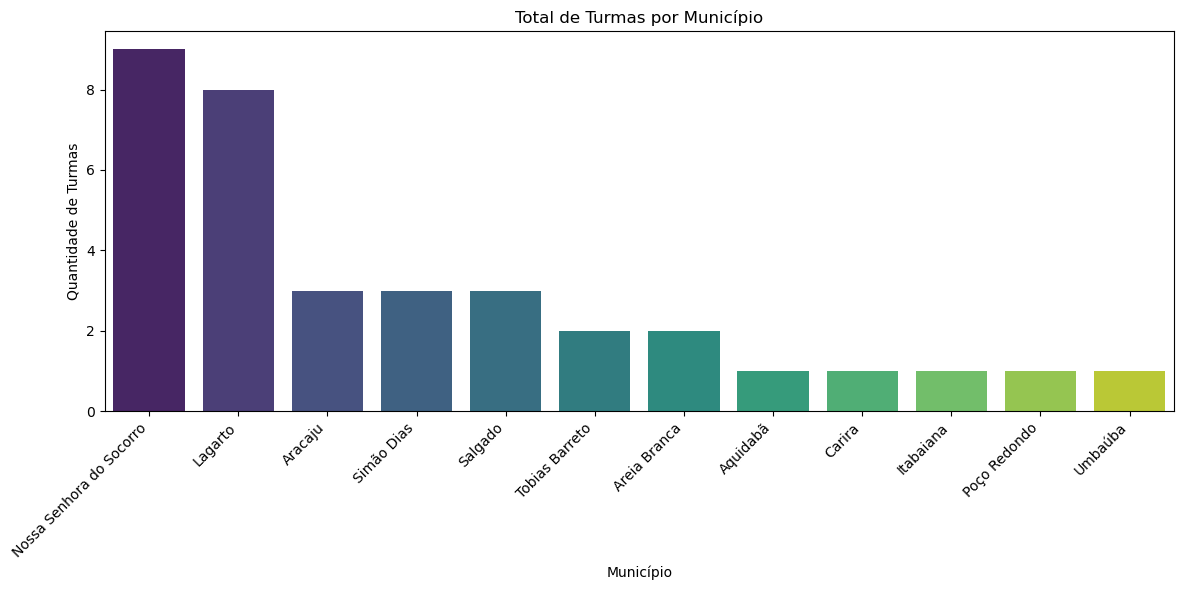

In [10]:
# Criando diretório para salvar os gráficos
output_dir_relatorio_23 = "Data_files/graficos_relatorio_2.3_35_turmas"
os.makedirs(output_dir_relatorio_23, exist_ok=True)

# Criando gráfico de total de turmas por município
plt.figure(figsize=(12, 6))
sns.barplot(data=turmas_por_unidade.sort_values('total_turmas', ascending=False),
            x='municipio', y='total_turmas', palette='viridis')
plt.title('Total de Turmas por Município')
plt.xlabel('Município')
plt.ylabel('Quantidade de Turmas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{output_dir_relatorio_23}/total_por_municipio.png', dpi=300)
plt.show()

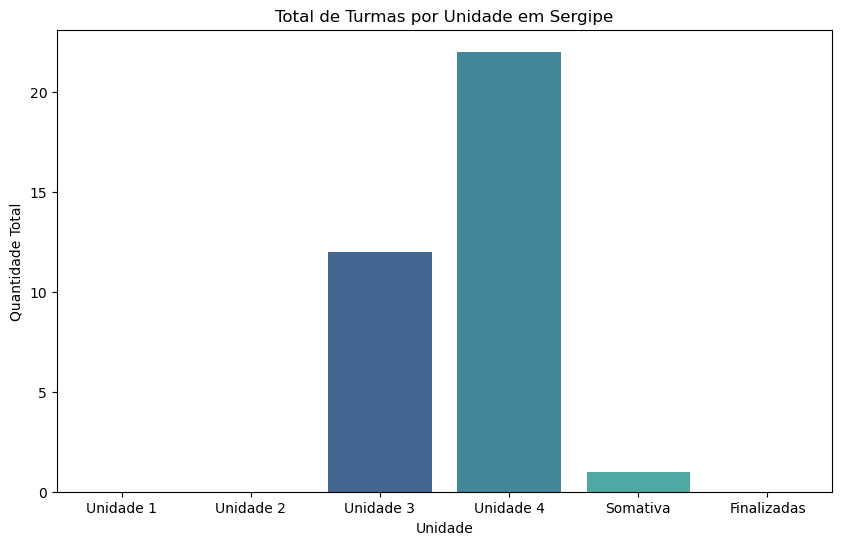

Total de turmas contabilizadas: 35


,municipio,turmas_em_unid_1,turmas_em_unid_2,turmas_em_unid_3,turmas_em_unid_4,turmas_em_somativa,turmas_finalizadas,total_turmas
0,Aquidabã,0,0,1,0,0,0,1
1,Aracaju,0,0,2,1,0,0,3
2,Areia Branca,0,0,2,0,0,0,2
3,Carira,0,0,1,0,0,0,1
4,Itabaiana,0,0,1,0,0,0,1
5,Lagarto,0,0,0,8,0,0,8
6,Nossa Senhora do Socorro,0,0,0,8,1,0,9
7,Poço Redondo,0,0,1,0,0,0,1
8,Salgado,0,0,3,0,0,0,3
9,Simão Dias,0,0,0,3,0,0,3


In [11]:
# Criando gráfico de total de turmas em cada unidade
# Gráfico 2: Total de turmas por unidade (com rótulos personalizados)
df_unidades = turmas_por_unidade.melt(
    id_vars=['municipio'],
    value_vars=['turmas_em_unid_1', 'turmas_em_unid_2', 'turmas_em_unid_3', 'turmas_em_unid_4', 'turmas_em_somativa', 'turmas_finalizadas'],
    var_name='Unidade',
    value_name='Quantidade'
)

# Mapear nomes das unidades
mapeamento_unidades = {
    'turmas_em_unid_1': 'Unidade 1',
    'turmas_em_unid_2': 'Unidade 2',
    'turmas_em_unid_3': 'Unidade 3',
    'turmas_em_unid_4': 'Unidade 4',
    'turmas_em_somativa': 'Somativa', 
    'turmas_finalizadas': 'Finalizadas'
}
df_unidades['Unidade'] = df_unidades['Unidade'].map(mapeamento_unidades)

# Plotar o gráfico (sem warnings!)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_unidades,
    x='Unidade',
    y='Quantidade',
    hue='Unidade',      # Adicionado para evitar o warning
    estimator=sum,
    errorbar=None,
    palette='mako',
    legend=False        # Remove legenda redundante
)
plt.title('Total de Turmas por Unidade em Sergipe')
plt.xlabel('Unidade')
plt.ylabel('Quantidade Total')
plt.savefig(f'{output_dir_relatorio_23}/total_turmas_por_unidade_sergipe.png', dpi=300)
#plt.close()
plt.show()

print(f"Total de turmas contabilizadas: {turmas_por_unidade['total_turmas'].sum()}")

turmas_por_unidade

In [12]:
# Criando um gráfico por município para mostrar número de turmas em cada unidade
# Criar um gráfico para cada município
for municipio in turmas_por_unidade['municipio'].unique():
    # Filtrar dados do município
    df_municipio = turmas_por_unidade[turmas_por_unidade['municipio'] == municipio]
    
    # Transformar os dados para formato longo (melt) e aplicar mapeamento
    df_melted = df_municipio.melt(
        id_vars=['municipio'], 
        value_vars=['turmas_em_unid_1', 'turmas_em_unid_2', 'turmas_em_unid_3', 'turmas_em_unid_4', 'turmas_em_somativa'],
        var_name='Unidade', 
        value_name='Quantidade'
    )
    
    # Aplicar os novos nomes das unidades
    df_melted['Unidade'] = df_melted['Unidade'].map(mapeamento_unidades)
    
    # Ordenar as unidades
    df_melted['Unidade'] = pd.Categorical(
        df_melted['Unidade'],
        categories=['Unidade 1', 'Unidade 2', 'Unidade 3', 'Unidade 4', 'Somativa'],
        ordered=True
    )
    
    # Configurar o gráfico (versão atualizada do Seaborn)
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=df_melted,
        x='Unidade',
        y='Quantidade',
        hue='Unidade',  # Adicionado para evitar o warning
        palette='rocket',
        legend=False    # Não mostra a legenda redundante
    )
    
    # Adicionar título e rótulos
    plt.title(f'Distribuição de Turmas em {municipio}')
    plt.xlabel('Unidade')
    plt.ylabel('Quantidade de Turmas')
    
    # Salvar o gráfico
    nome_arquivo = f"turmas_por_unidade_{municipio.lower().replace(' ', '_').replace('ã', 'a').replace('ç', 'c')}.png"
    plt.tight_layout()
    plt.savefig(f'{output_dir_relatorio_23}/{nome_arquivo}', dpi=300)
    plt.close()


##### Estudando os dados por estado
Agora vamos entender os dados de cada município. Dessa forma, nosso objetivo aqui é:
- Entender a quantidade de alunos por município e sua proporção em relação ao programa como um todo;
- Entender a quantidade de turmas por município e sua proporção em relação ao programa como um todo;
- Entender a relevância dos alunos perante o total de alunos enturmados em Sergipe;
- Gerar os resultados dos registros por atividade estruturada por município;
- Gerar os resultados de perfil de turma por município e entender se os perfis são diferentes.

##### Entendendo alunos e turmas por município


#### Atividade Estruturada Formativa 1

Primeiramente, vamos construir uma tabela contando as quantidades de cada nível para cada formativa, considerando a linguagem, municipio e a turma.

In [13]:
# Calculando moda dos níveis para cada linguagem
def calcular_moda_nivel(df, form_number):
    """
    Calcula a moda da coluna 'nivel' para um dataframe de formulário específico.
    
    Args:
        df: DataFrame com os registros do formulário
        form_number: Número do formulário (1, 2, 3 ou 4)
    
    Returns:
        DataFrame com as modas calculadas
    """
    moda_df = (
        df.groupby(['cpf', 'nome', 'turma', 'municipio', 'linguagem'])['nivel']
        .agg(lambda x: x.mode().iloc[0])
        .reset_index()
    )
    return moda_df

# Calcular modas para cada formulário
moda_form_1 = calcular_moda_nivel(df_registros_form_1, 1)
moda_form_2 = calcular_moda_nivel(df_registros_form_2, 2)
moda_form_3 = calcular_moda_nivel(df_registros_form_3, 3)
moda_form_4 = calcular_moda_nivel(df_registros_form_4, 4)

# Contando níveis por formativa
def contar_niveis_por_form(df, form_number):
    # Conta a ocorrência de cada nível, mantendo as colunas de agrupamento
    # Adicionando observed=True para evitar o warning
    contagem = (
        df.groupby(['turma', 'municipio', 'linguagem', 'nivel'], observed=True)
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    
    # Renomeia as colunas de nível para incluir o número do formulário
    nivel_cols = [col for col in contagem.columns if col not in ['turma', 'municipio', 'linguagem']]
    rename_dict = {col: f'form_{form_number}_{col}' for col in nivel_cols}
    contagem = contagem.rename(columns=rename_dict)
    
    return contagem

# Aplicar a função para cada formulário
contagem_form_1 = contar_niveis_por_form(moda_form_1, 1)
contagem_form_2 = contar_niveis_por_form(moda_form_2, 2)
contagem_form_3 = contar_niveis_por_form(moda_form_3, 3)
contagem_form_4 = contar_niveis_por_form(moda_form_4, 4)

# Combinar os resultados com outer join
df_contagem_completa = (
    contagem_form_1
    .merge(contagem_form_2, 
           on=['turma', 'municipio', 'linguagem'], 
           how='outer',
           suffixes=('', '_form2'))
    .merge(contagem_form_3, 
           on=['turma', 'municipio', 'linguagem'],
           how='outer',
           suffixes=('', '_form3'))
    .merge(contagem_form_4, 
           on=['turma', 'municipio', 'linguagem'],
           how='outer',
           suffixes=('', '_form4'))
    .fillna(0)
)

# Limpeza final dos nomes das colunas
df_contagem_completa.columns = [col.replace('_form2', '_form_2').replace('_form3', '_form_3').replace('_form4', '_form_4') 
                               for col in df_contagem_completa.columns]

# Ordenação final
df_contagem_completa = df_contagem_completa.sort_values(
    by=['turma', 'municipio', 'linguagem']
).reset_index(drop=True)

# Separando por linguagem
#df_analise_linguistica = df_contagem_completa[df_contagem_completa['linguagem'] == 'Análise linguística'].reset_index(drop=True)
df_analise_linguistica = df_contagem_completa[df_contagem_completa['linguagem'] == 'Análise linguística'].drop(['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3', 'form_4_Nível 2', 'form_4_Nível 3'], axis=1).reset_index(drop=True)
df_oralidade_leitura_13 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_4_Nível 2', 'form_4_Nível 3'], axis=1).reset_index(drop=True)
#df_oralidade_leitura_14 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3'], axis=1).reset_index(drop=True)
#df_oralidade_leitura_34 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3', 'form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3'], axis=1).reset_index(drop=True)
#df_producao_escrita = df_contagem_completa[df_contagem_completa['linguagem'] == 'Produção escrita'].drop(['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3', 'form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3'], axis=1).reset_index(drop=True)

# Criando função para remover turmas sem dados
def remover_turmas_sem_dados(df, turmas_sem_dados):
    linhas_a_remover = df[
        df['turma'].isin(turmas_sem_dados)
    ].index
    return df.drop(linhas_a_remover)

# Aplicando a função para remover turmas sem dados
df_oralidade_leitura_13 = remover_turmas_sem_dados(df_oralidade_leitura_13, sem_dados)

# Contando número total de alunos por turma com base na Formativa 1
df_analise_linguistica['total_alunos_form_1'] = df_analise_linguistica[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum(axis=1)
df_analise_linguistica['total_alunos_form_2'] = df_analise_linguistica[['form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3']].sum(axis=1)
df_oralidade_leitura_13['total_alunos_form_1'] = df_oralidade_leitura_13[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum(axis=1)
df_oralidade_leitura_13['total_alunos_form_3'] = df_oralidade_leitura_13[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum(axis=1)
#df_oralidade_leitura_14['total_alunos_form_1'] = df_oralidade_leitura_14[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum(axis=1)
#df_oralidade_leitura_14['total_alunos_form_4'] = df_oralidade_leitura_14[['form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3']].sum(axis=1)
#df_oralidade_leitura_34['total_alunos_form_3'] = df_oralidade_leitura_34[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum(axis=1)
#df_oralidade_leitura_34['total_alunos_form_4'] = df_oralidade_leitura_34[['form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3']].sum(axis=1)
#df_producao_escrita['total_alunos_form_3'] = df_producao_escrita[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum(axis=1)
#df_producao_escrita['total_alunos_form_4'] = df_producao_escrita[['form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3']].sum(axis=1)

# Retirando turmas que não contém dados
#df_analise_linguistica = df_analise_linguistica[
#    df_analise_linguistica['turma'].isin(
#        list(ls_turmas_unid_3) + 
#        list(ls_turmas_unid_4) + 
#        list(ls_turmas_somativa))]


In [14]:
# Retirando turma com erro de dados na formativa 3
df_oralidade_leitura_13 = df_oralidade_leitura_13.drop(
    df_oralidade_leitura_13[df_oralidade_leitura_13['turma'] == 'TURMA-28005201-0006'].index
)


#### Produção de texto

Gráfico salvo: Data_files/graficos_relatorio_2.3_35_turmas/grafico_producao_escrita.png

Todos os gráficos foram salvos no diretório: Data_files/graficos_relatorio_2.3_35_turmas


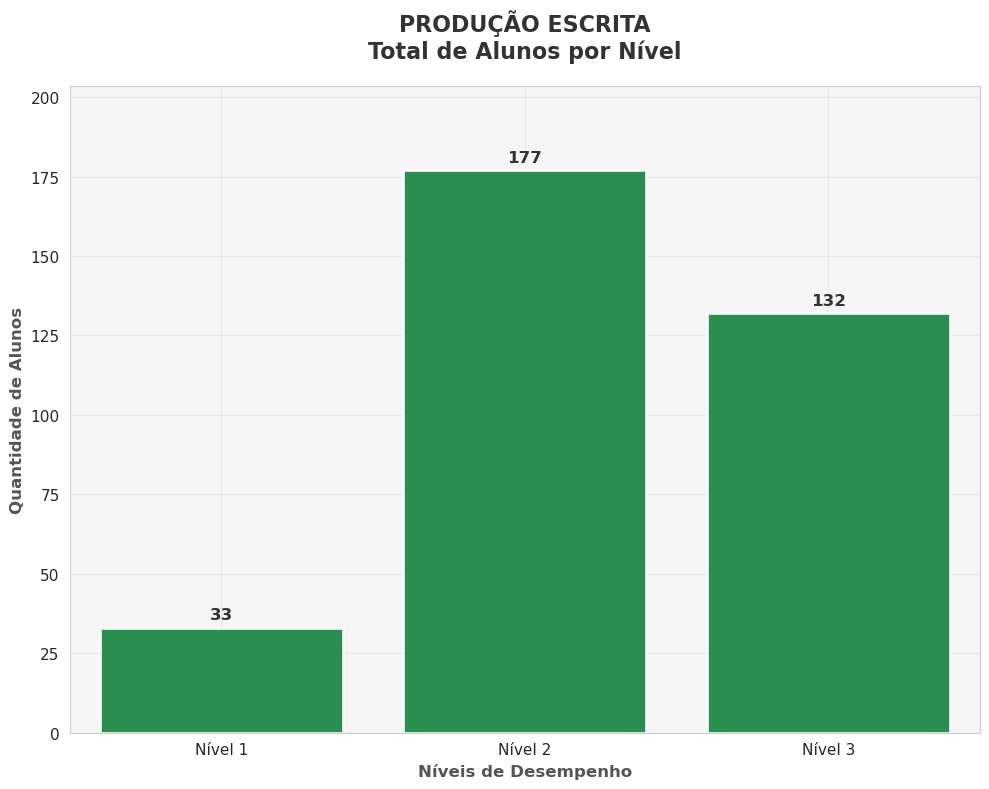

In [15]:
# Configuração do estilo com tema elegante usando cores de Sergipe
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

# Cores da bandeira de Sergipe
verde_sergipe = '#009639'  # Verde oficial
amarelo_sergipe = '#FEDF00'  # Amarelo oficial
cinza_claro = '#f5f5f5'
cinza_fundo = '#fafafa'

# Função para criar e salvar gráficos individuais
def criar_grafico_linguagem(linguagem, cor, filename):
    """Cria e salva gráfico para uma linguagem específica"""
    
    # Filtrar e somar os dados
    dados_filtrados = contagem_form_3[contagem_form_3['linguagem'] == linguagem]
    soma_niveis = dados_filtrados[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum()
    
    # Criar DataFrame para o gráfico
    df_grafico = pd.DataFrame({
        'Nível': ['Nível 1', 'Nível 2', 'Nível 3'],
        'Quantidade': soma_niveis.values
    })
    
    # Criar figura
    plt.figure(figsize=(10, 8))
    ax = plt.gca()
    
    # Criar gráfico de barras
    bars = sns.barplot(
        data=df_grafico,
        x='Nível',
        y='Quantidade',
        color=cor,
        edgecolor='white',
        linewidth=2,
        alpha=0.9
    )
    
    # Personalizar título e labels
    titulo = linguagem.upper()
    plt.title(f'{titulo}\nTotal de Alunos por Nível', 
              fontsize=16, fontweight='bold', pad=20, color='#333333')
    plt.xlabel('Níveis de Desempenho', fontsize=12, fontweight='bold', color='#555555')
    plt.ylabel('Quantidade de Alunos', fontsize=12, fontweight='bold', color='#555555')
    
    # Personalizar eixos
    ax.set_facecolor(cinza_claro)
    ax.tick_params(axis='both', which='major', labelsize=11)
    
    # Adicionar valores nas barras
    max_val = df_grafico['Quantidade'].max()
    for i, valor in enumerate(df_grafico['Quantidade']):
        plt.text(i, valor + max_val * 0.01, f'{valor}', 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='#333333')
    
    # Ajustar limite do eixo Y
    plt.ylim(0, max_val * 1.15)
    
    # Adicionar grid sutil
    plt.grid(True, alpha=0.3)
    
    # Ajustar layout
    plt.tight_layout()
    
    # Salvar gráfico
    caminho_completo = os.path.join(output_dir_relatorio_23, filename)
    plt.savefig(caminho_completo, dpi=300, bbox_inches='tight', facecolor='white')
        
    print(f"Gráfico salvo: {caminho_completo}")

# Criar e salvar gráfico para Oralidade e leitura (verde)
criar_grafico_linguagem(
    linguagem='Produção escrita',
    cor=verde_sergipe,
    filename='grafico_producao_escrita.png'
)

print(f"\nTodos os gráficos foram salvos no diretório: {output_dir_relatorio_23}")
plt.show()
plt.close()

In [16]:
# Criando gráficos para Produção Escrita para cada município
# Configuração do estilo
sns.set_style("white")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titleweight'] = 'bold'

# Lista de municípios únicos
municipios = contagem_form_3['municipio'].unique()

# Função para criar gráfico por município e linguagem
def criar_grafico_municipio_linguagem(municipio, linguagem, cor):
    """Cria gráfico para um município e linguagem específicos"""
    
    # Filtrar dados
    dados_filtrados = contagem_form_3[
        (contagem_form_3['municipio'] == municipio) & 
        (contagem_form_3['linguagem'] == linguagem)
    ]
    
    if dados_filtrados.empty:
        return
    
    # Somar os níveis (pode haver múltiplas turmas no mesmo município)
    soma_niveis = dados_filtrados[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum()
    
    # Criar figura
    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor('white')
    
    # Criar gráfico de barras
    bars = ax.bar(['NÍVEL 1', 'NÍVEL 2', 'NÍVEL 3'], soma_niveis.values,
                 color=cor, alpha=0.85, edgecolor='white', linewidth=2.5)
    
    # Configurações do gráfico
    ax.set_facecolor(cinza_fundo)
    
    # Título baseado na linguagem

    linguagem == 'Produção escrita'
    titulo = f'PRODUÇÃO ESCRITA\n{municipio.upper()}'
    filename = f'producao_escrita_{municipio.lower().replace(" ", "_")}.png'

    ax.set_title(titulo, fontsize=16, pad=20, color='#2d2d2d')
    ax.set_ylabel('QUANTIDADE DE ALUNOS', fontsize=12, color='#555555')
    ax.set_xlabel('NÍVEIS DE DESEMPENHO', fontsize=12, color='#555555')
    
    # Estilizar eixos
    ax.tick_params(axis='x', labelsize=11, labelcolor='#444444')
    ax.tick_params(axis='y', labelsize=10, labelcolor='#666666')
    
    # Remover bordas desnecessárias
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color('#dddddd')
    
    # Adicionar valores nas barras
    max_val = max(soma_niveis.values) if max(soma_niveis.values) > 0 else 1
    for i, bar in enumerate(bars):
        height = bar.get_height()
        if height > 0:  # Só adiciona texto se houver valor
            ax.text(bar.get_x() + bar.get_width()/2., height + max_val*0.02,
                   f'{int(height)}', ha='center', va='bottom', 
                   fontsize=11, fontweight='bold', color='#2d2d2d')
    
    # Grid sutil
    ax.grid(axis='y', alpha=0.2, linestyle='--')
    
    # Ajustar limite do eixo Y
    ax.set_ylim(0, max_val * 1.15)
    
    # Layout
    plt.tight_layout()
    
    # Salvar gráfico
    caminho_completo = os.path.join(output_dir_relatorio_23, filename)
    plt.savefig(caminho_completo, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    
    return filename

# Criar gráficos para todos os municípios
graficos_criados = []

for municipio in municipios:
    print(f"💾 Criando gráficos para: {municipio}")
    
    # Gráfico de Produção escrita
    arquivo_producao_escrita = criar_grafico_municipio_linguagem(
        municipio, 'Produção escrita', verde_sergipe
    )
    if arquivo_producao_escrita:
        graficos_criados.append(arquivo_producao_escrita)

# Relatório final
print(f"\n✅ Processo concluído!")
print(f"📁 Diretório: {output_dir_relatorio_23}")
print(f"📊 Total de gráficos criados: {len(graficos_criados)}")
print(f"🏙️  Municípios processados: {len(municipios)}")


💾 Criando gráficos para: Simão Dias
💾 Criando gráficos para: Tobias Barreto
💾 Criando gráficos para: Lagarto
💾 Criando gráficos para: Nossa Senhora do Socorro
💾 Criando gráficos para: Aracaju

✅ Processo concluído!
📁 Diretório: Data_files/graficos_relatorio_2.3_35_turmas
📊 Total de gráficos criados: 5
🏙️  Municípios processados: 5


In [17]:
contagem_form_3[contagem_form_3['linguagem'] == "Produção escrita"].groupby('municipio')[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum()

nivel,form_3_Nível 1,form_3_Nível 2,form_3_Nível 3
municipio,,,
Aracaju,0,5,5
Lagarto,8,60,54
Nossa Senhora do Socorro,8,62,55
Simão Dias,8,37,9
Tobias Barreto,9,13,9


#### Teste estatístico


=== ANÁLISE CONSIDERANDO ORALIDADE E LEITURA PARA 35 TURMAS NO ESTADO DE SERGIPE ===

Teste de Wilcoxon para Nível 1:
Estatística = 50.000, p-valor = 0.1221
Não há diferença significativa (p ≥ 0.05) nas proporções de Nível 1 entre os testes.
---
Teste de Wilcoxon para Nível 2:
Estatística = 135.000, p-valor = 0.9406
Não há diferença significativa (p ≥ 0.05) nas proporções de Nível 2 entre os testes.
---
Teste de Wilcoxon para Nível 3:
Estatística = 67.000, p-valor = 0.0918
Não há diferença significativa (p ≥ 0.05) nas proporções de Nível 3 entre os testes.
---

=== ANÁLISE CONSIDERANDO ORALIDADE E LEITURA POR MUNICÍPIO ===


Município: Simão Dias

Nível 1:
Estatística = 0.000, p-valor = 0.5000
Não há diferença significativa (p ≥ 0.05) em Simão Dias.

Nível 2:
Estatística = 1.000, p-valor = 0.5000
Não há diferença significativa (p ≥ 0.05) em Simão Dias.

Nível 3:
Estatística = 2.000, p-valor = 0.7500
Não há diferença significativa (p ≥ 0.05) em Simão Dias.

Município: Tobias Barreto
Nú

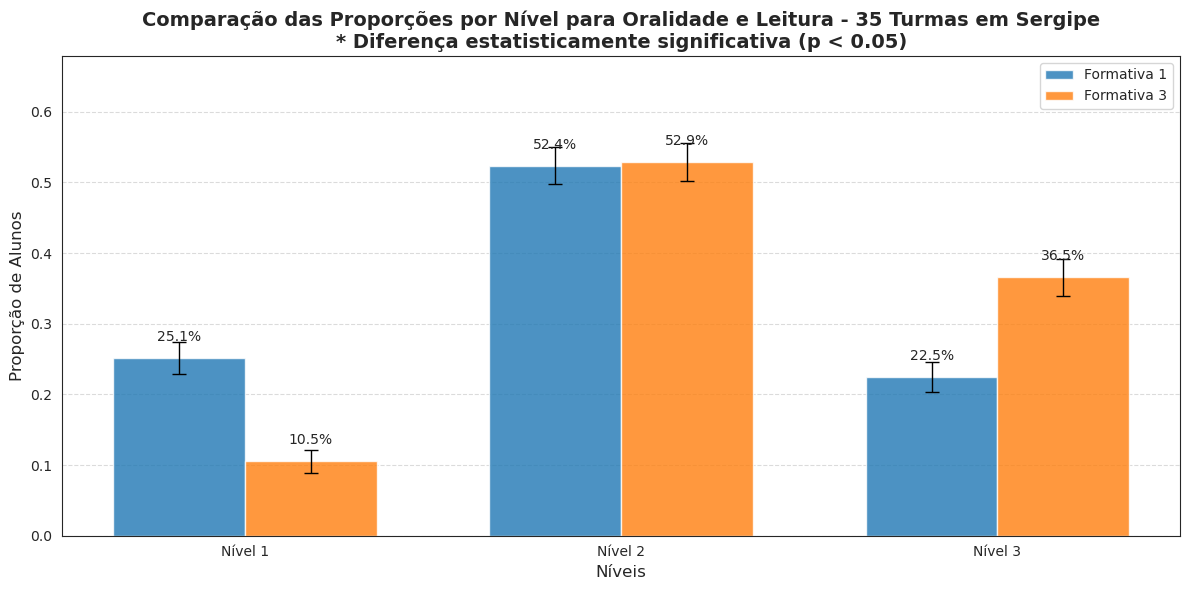

In [18]:
## Calcular proporções para cada nível em cada teste
for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
    df_oralidade_leitura_13[f'prop_form_1_{nivel}'] = df_oralidade_leitura_13[f'form_1_{nivel}'] / df_oralidade_leitura_13['total_alunos_form_1']
    df_oralidade_leitura_13[f'prop_form_3_{nivel}'] = df_oralidade_leitura_13[f'form_3_{nivel}'] / df_oralidade_leitura_13['total_alunos_form_3']

# 1. Análise para todo o estado
print("\n=== ANÁLISE CONSIDERANDO ORALIDADE E LEITURA PARA 35 TURMAS NO ESTADO DE SERGIPE ===\n")

# Teste de Wilcoxon para amostras pareadas (comparando as proporções de cada turma)
for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
    stat, p = wilcoxon(df_oralidade_leitura_13[f'prop_form_1_{nivel}'], 
                       df_oralidade_leitura_13[f'prop_form_3_{nivel}'])
    print(f"Teste de Wilcoxon para {nivel}:")
    print(f"Estatística = {stat:.3f}, p-valor = {p:.4f}")
    if p < 0.05:
        print(f"Há diferença significativa (p < 0.05) nas proporções de {nivel} entre os testes.")
        # Verificar a direção da diferença
        median_diff = (df_oralidade_leitura_13[f'prop_form_3_{nivel}'] - df_oralidade_leitura_13[f'prop_form_1_{nivel}']).median()
        if median_diff > 0:
            print(f"A proporção de alunos no {nivel} AUMENTOU significativamente no teste 2.")
        else:
            print(f"A proporção de alunos no {nivel} DIMINUIU significativamente no teste 2.")
    else:
        print(f"Não há diferença significativa (p ≥ 0.05) nas proporções de {nivel} entre os testes.")
    print("---")

# 2. Análise por município
print("\n=== ANÁLISE CONSIDERANDO ORALIDADE E LEITURA POR MUNICÍPIO ===\n")

for municipio in df_oralidade_leitura_13['municipio'].unique():
    print(f"\nMunicípio: {municipio}")
    df_municipio = df_oralidade_leitura_13[df_oralidade_leitura_13['municipio'] == municipio]
    
    if len(df_municipio) < 3:  # Muito poucas turmas para análise
        print("Número de turmas insuficiente para análise estatística.")
        continue
    
    for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
        stat, p = wilcoxon(df_municipio[f'prop_form_1_{nivel}'], 
                           df_municipio[f'prop_form_3_{nivel}'])
        print(f"\n{nivel}:")
        print(f"Estatística = {stat:.3f}, p-valor = {p:.4f}")
        if p < 0.05:
            print(f"Há diferença significativa (p < 0.05) em {municipio}.")
            median_diff = (df_municipio[f'prop_form_3_{nivel}'] - df_municipio[f'prop_form_1_{nivel}']).median()
            if median_diff > 0:
                print(f"A proporção de alunos no {nivel} AUMENTOU significativamente no teste 2.")
            else:
                print(f"A proporção de alunos no {nivel} DIMINUIU significativamente no teste 2.")
        else:
            print(f"Não há diferença significativa (p ≥ 0.05) em {municipio}.")

# 3. Análise de transição entre níveis (para todo o estado)
print("\n=== ANÁLISE DE TRANSIÇÃO ENTRE NÍVEIS PARA ORALIDADE E LEITURA (ESTADO) ===\n")

# Calcular totais estaduais para cada nível
totais_estado = {
    'form_1_Nível 1': df_oralidade_leitura_13['form_1_Nível 1'].sum(),
    'form_1_Nível 2': df_oralidade_leitura_13['form_1_Nível 2'].sum(),
    'form_1_Nível 3': df_oralidade_leitura_13['form_1_Nível 3'].sum(),
    'form_3_Nível 1': df_oralidade_leitura_13['form_3_Nível 1'].sum(),
    'form_3_Nível 2': df_oralidade_leitura_13['form_3_Nível 2'].sum(),
    'form_3_Nível 3': df_oralidade_leitura_13['form_3_Nível 3'].sum(),
    'total_form_1': df_oralidade_leitura_13['total_alunos_form_1'].sum(),
    'total_form_3': df_oralidade_leitura_13['total_alunos_form_3'].sum()
}

# Teste qui-quadrado para tabelas de contingência (comparando distribuição dos níveis)
print("Teste qui-quadrado para distribuição dos níveis entre form_1 e form_3:")

# Criar tabela de contingência
contingency_table = np.array([
    [totais_estado['form_1_Nível 1'], totais_estado['form_1_Nível 2'], totais_estado['form_1_Nível 3']],
    [totais_estado['form_3_Nível 1'], totais_estado['form_3_Nível 2'], totais_estado['form_3_Nível 3']]
])

chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Qui-quadrado = {chi2:.3f}, p-valor = {p:.4f}")
if p < 0.05:
    print("Há diferença significativa (p < 0.05) na distribuição dos níveis entre os testes.")
    print("Tabela observada:")
    print(contingency_table)
    print("\nTabela esperada sob a hipótese nula:")
    print(expected.round(1))
    
    # Calcular resíduos padronizados para identificar onde estão as diferenças
    residuals = (contingency_table - expected) / np.sqrt(expected)
    print("\nResíduos padronizados (valores absolutos >2 indicam diferenças significativas):")
    print(residuals.round(2))
else:
    print("Não há diferença significativa (p ≥ 0.05) na distribuição dos níveis entre os testes.")

# Visualização dos resultados com barras de erro
plt.figure(figsize=(12, 6))

# Proporções estaduais
prop_form_1 = [totais_estado['form_1_Nível 1']/totais_estado['total_form_1'],
               totais_estado['form_1_Nível 2']/totais_estado['total_form_1'],
               totais_estado['form_1_Nível 3']/totais_estado['total_form_1']]

prop_form_3 = [totais_estado['form_3_Nível 1']/totais_estado['total_form_3'],
               totais_estado['form_3_Nível 2']/totais_estado['total_form_3'],
               totais_estado['form_3_Nível 3']/totais_estado['total_form_3']]

# Calcular erros padrão para cada proporção
# Para proporções, o erro padrão é sqrt(p*(1-p)/n)
def calc_erro_proporcao(p, n):
    return np.sqrt(p * (1 - p) / n)

erro_form_1 = [calc_erro_proporcao(p, totais_estado['total_form_1']) for p in prop_form_1]
erro_form_3 = [calc_erro_proporcao(p, totais_estado['total_form_3']) for p in prop_form_3]

bar_width = 0.35
index = np.arange(3)

# Criar barras com erro
bars1 = plt.bar(index, prop_form_1, bar_width, label='Formativa 1', alpha=0.8, color='#1f77b4',
               yerr=erro_form_1, capsize=5, error_kw={'elinewidth': 1, 'capthick': 1})

bars2 = plt.bar(index + bar_width, prop_form_3, bar_width, label='Formativa 3', alpha=0.8, color='#ff7f0e',
               yerr=erro_form_3, capsize=5, error_kw={'elinewidth': 1, 'capthick': 1})

# Adicionar valores nas barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,  # Adicione um offset de 0.02 (2%)
                f'{height:.1%}',
                ha='center', va='bottom', fontsize=10)

# Testar cada nível separadamente com Wilcoxon
niveis_significativos = []
for i, nivel in enumerate(['Nível 1', 'Nível 2', 'Nível 3']):
    stat, p_nivel = wilcoxon(df_oralidade_leitura_13[f'prop_form_1_{nivel}'], 
                            df_oralidade_leitura_13[f'prop_form_3_{nivel}'])
    if p_nivel < 0.05:
        niveis_significativos.append(i)
        y_pos = max(prop_form_1[i], prop_form_3[i]) + 0.05
        plt.text(index[i] + bar_width/2, y_pos, '*', 
                ha='center', va='bottom', fontsize=16, color='red')

# Personalizar
plt.xlabel('Níveis', fontsize=12)
plt.ylabel('Proporção de Alunos', fontsize=12)
plt.title('Comparação das Proporções por Nível para Oralidade e Leitura - 35 Turmas em Sergipe\n* Diferença estatisticamente significativa (p < 0.05)', fontsize=14)
plt.xticks(index + bar_width/2, ['Nível 1', 'Nível 2', 'Nível 3'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(prop_form_1 + prop_form_3) + 0.15)  # Ajuste para acomodar as barras de erro

# Salvando gráfico
plt.savefig(f'{output_dir_relatorio_23}/teste_wilcoxon_oralidade_leitura_13_35_sergipe.png', dpi=300)

# Exibindo gráfico
plt.tight_layout()
plt.show()


In [19]:
# Testando Oralidade e Leitura e criando gráficos para cada município
# Função para criar e salvar gráficos por município
def criar_graficos_municipios(df, output_dir):
    # Agrupar dados por município
    grouped = df.groupby('municipio')
    
    for municipio, group in grouped:
        # Calcular totais para o município
        totais_municipio = {
            'form_1_Nível 1': group['form_1_Nível 1'].sum(),
            'form_1_Nível 2': group['form_1_Nível 2'].sum(),
            'form_1_Nível 3': group['form_1_Nível 3'].sum(),
            'form_3_Nível 1': group['form_3_Nível 1'].sum(),
            'form_3_Nível 2': group['form_3_Nível 2'].sum(),
            'form_3_Nível 3': group['form_3_Nível 3'].sum(),
            'total_form_1': group['total_alunos_form_1'].sum(),
            'total_form_3': group['total_alunos_form_3'].sum()
        }
        
        # Calcular proporções
        prop_form_1 = [
            totais_municipio['form_1_Nível 1']/totais_municipio['total_form_1'],
            totais_municipio['form_1_Nível 2']/totais_municipio['total_form_1'],
            totais_municipio['form_1_Nível 3']/totais_municipio['total_form_1']
        ]
        
        prop_form_3 = [
            totais_municipio['form_3_Nível 1']/totais_municipio['total_form_3'],
            totais_municipio['form_3_Nível 2']/totais_municipio['total_form_3'],
            totais_municipio['form_3_Nível 3']/totais_municipio['total_form_3']
        ]
        
        # Calcular erros padrão
        def calc_erro(p, n):
            return np.sqrt(p * (1 - p) / n) if n > 0 else 0
            
        erro_form_1 = [calc_erro(p, totais_municipio['total_form_1']) for p in prop_form_1]
        erro_form_3 = [calc_erro(p, totais_municipio['total_form_3']) for p in prop_form_3]
        
        # Criar figura
        plt.figure(figsize=(10, 6))
        
        # Configurações do gráfico
        bar_width = 0.35
        index = np.arange(3)
        
        # Criar barras
        bars1 = plt.bar(index, prop_form_1, bar_width, label='Formativa 1', color='#1f77b4',
                       yerr=erro_form_1, capsize=5, alpha=0.7)
        bars2 = plt.bar(index + bar_width, prop_form_3, bar_width, label='Formativa 3', color='#ff7f0e',
                       yerr=erro_form_3, capsize=5, alpha=0.7)
        
        # Adicionar valores nas barras
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height + 0.03,
                         f'{height:.1%}',
                         ha='center', va='bottom', fontsize=9)
        
        # Verificar significância por nível
        niveis_significativos = []
        for i, nivel in enumerate(['Nível 1', 'Nível 2', 'Nível 3']):
            if len(group) >= 3:  # Só testar se tiver turmas suficientes
                stat, p_nivel = wilcoxon(group[f'prop_form_1_{nivel}'], 
                                        group[f'prop_form_3_{nivel}'])
                if p_nivel < 0.05:
                    niveis_significativos.append(i)
                    y_pos = max(prop_form_1[i], prop_form_3[i]) + 0.05
                    plt.text(index[i] + bar_width/2, y_pos, '*', 
                            ha='center', va='bottom', fontsize=14, color='red')
            
        plt.xlabel('Níveis', fontsize=10)
        plt.ylabel('Proporção de Alunos', fontsize=10)
        plt.title(f'Comparação das Proporções por Nível para Oralidade e Leitura - {municipio}\n* Diferença estatisticamente significativa (p < 0.05)', fontsize=12)
        plt.xticks(index + bar_width/2, ['Nível 1', 'Nível 2', 'Nível 3'])
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Ajustar layout e salvar
        plt.tight_layout()
        
        # Criar nome do arquivo (substituir caracteres inválidos)
        filename = f"teste_wilcoxon_oralidade_leitura_13_35_{municipio.replace(' ', '_').replace('/', '_')}.png"
        filepath = os.path.join(output_dir_relatorio_23, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"Gráfico salvo em: {filepath}")

# Chamar a função para criar os gráficos
criar_graficos_municipios(df_oralidade_leitura_13, output_dir_relatorio_23)

Gráfico salvo em: Data_files/graficos_relatorio_2.3_35_turmas/teste_wilcoxon_oralidade_leitura_13_35_Aracaju.png
Gráfico salvo em: Data_files/graficos_relatorio_2.3_35_turmas/teste_wilcoxon_oralidade_leitura_13_35_Lagarto.png
Gráfico salvo em: Data_files/graficos_relatorio_2.3_35_turmas/teste_wilcoxon_oralidade_leitura_13_35_Nossa_Senhora_do_Socorro.png
Gráfico salvo em: Data_files/graficos_relatorio_2.3_35_turmas/teste_wilcoxon_oralidade_leitura_13_35_Simão_Dias.png
Gráfico salvo em: Data_files/graficos_relatorio_2.3_35_turmas/teste_wilcoxon_oralidade_leitura_13_35_Tobias_Barreto.png
